# Calibrating and validating fade margins

A fade margin is an upper quantile forecast of the path-loss deviation `y` from the link's anchor, the previous-hour mean. This notebook builds the margin in the usual ways and tests each one the way a quantile forecast is tested, instead of comparing mean margins at unmatched coverage.

* **Base predictors**, both on rung H4 of `12_History_Features`: a LightGBM regression, with one margin on top of it, and LightGBM quantile models at the target level.
* **Calibrations of the shift**, all from earlier packets only: one pooled shift (split conformal, as in conformalised quantile regression), one shift per group, a recency-weighted shift, and adaptive conformal inference run per link. The groups are spreading factor x working hours, and the same split by recent-spread tercile, which makes the margin a lookup table of the state.
* **Rolling origin.** The shift of a window comes only from the validation folds before it, so validation folds 1 to 4 and the hold-out are five test windows.
* **Scores.** Coverage overall and by state, the mean margin, and the pinball loss, the consistent score of a quantile. Intervals are 95 % by resampling days, because packets of one day are not independent.
* **Backtests.** The chance of a miss right after a miss against after a covered packet (Christoffersen), and a logistic regression of the misses on the previous miss and the state, with errors clustered by day (conditional coverage).

The three target levels are 90, 95 and 99 %. The 99 % level carries the detailed tables.

In [1]:
import json
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from history_features import RUNGS
from margin_tools import (pinball, shift_pooled, shift_groups, shift_weighted, aci, spread_groups, day_codes, boot_stat,
                          transitions, clustering_ratio, christoffersen_independence, dynamic_binary_test)

RANDOM_STATE = 42
TARGETS = (0.90, 0.95, 0.99)
HALF_LIFE = 30          # days, recency-weighted shift
GAMMA_DIVISOR = 20      # adaptive conformal inference: step size (1 - target) / 20

In [2]:
# The rows, folds and inputs of notebooks 13 to 16
train = pd.read_csv("Data_Files/history_train.csv")
test = pd.read_csv("Data_Files/history_test.csv")
d = pd.concat([train, test], ignore_index=True)
d["t"] = pd.to_datetime(d["t"], utc=True)
d = d.sort_values("t").reset_index(drop=True)
fold = d["fold"].to_numpy()
H = {k.split()[0]: v for k, v in RUNGS.items()}
ok = (d["y"].notna() & d[H["H7"]].notna().all(axis=1)).to_numpy()          # an anchor and a complete input
y = d["y"].to_numpy()
X_all = d[H["H7"]].copy()
X = X_all.fillna(X_all[ok & (fold < 9)].median())[H["H4"]].to_numpy()       # rung H4: link history, channel, clock, SF
best = json.load(open("CV_Results/history_best_params.json"))["LGBM"]
link, sf, work, s20 = d["device_id"].to_numpy(), d["SF"].to_numpy().astype(int), d["work"].to_numpy().astype(int), d["s20"].to_numpy()
day = day_codes(d["t"])
print(f"packets with an anchor: {ok.sum():,}; validation folds 0-4: {(ok & (fold >= 0) & (fold < 9)).sum():,}; hold-out: {(ok & (fold == 9)).sum():,}")

packets with an anchor: 2,658,662; validation folds 0-4: 1,773,285; hold-out: 531,983


In [3]:
# Base predictors: out-of-fold for validation folds 0-4 (each fitted on the folds before it) and a fit on all training rows for the hold-out
def oof_and_test(make):
    p = np.full(len(d), np.nan)
    for k in range(5):
        tr, va = ok & (fold < k), ok & (fold == k)
        p[va] = make().fit(X[tr], y[tr]).predict(X[va])
    tr, ev = ok & (fold < 9), ok & (fold == 9)
    p[ev] = make().fit(X[tr], y[tr]).predict(X[ev])
    return p

params = dict(subsample_freq=1, random_state=RANDOM_STATE, n_jobs=8, verbose=-1, **best)      # 8 threads: LightGBM stalls when oversubscribed
t0 = time.time()
base = {"reg": oof_and_test(lambda: lgb.LGBMRegressor(**params))}
for tau in TARGETS:
    base[("q", tau)] = oof_and_test(lambda: lgb.LGBMRegressor(objective="quantile", alpha=tau, **params))
print(f"one regression and {len(TARGETS)} quantile models, each fitted six times: {time.time() - t0:.0f} s")

one regression and 3 quantile models, each fitted six times: 706 s


In [4]:
# Margins above the anchor for every window, target and method
windows = [1, 2, 3, 4, 9]

def state_codes(rows, cut):
    g1 = (sf[rows] - 7) * 2 + work[rows]                    # spreading factor x working hours
    return g1, g1 * 3 + spread_groups(s20[rows], cut)       # and the same split by recent-spread tercile

def calibrate(b, tau, cal, te, cut, half_life=HALF_LIFE, gamma_divisor=GAMMA_DIVISOR):
    """Base threshold b plus a shift from the scores of the earlier packets cal, five ways, for the packets te."""
    score = y[cal] - b[cal]
    g1_cal, g2_cal = state_codes(cal, cut)
    g1_te, g2_te = state_codes(te, cut)
    age = (d["t"].iloc[te].min() - d["t"].iloc[cal]).dt.total_seconds().to_numpy() / 86400
    out = {"pooled": b[te] + shift_pooled(score, tau),
           "SF x hours": b[te] + shift_groups(score, g1_cal, g1_te, tau),
           "state table": b[te] + shift_groups(score, g2_cal, g2_te, tau),
           "recency": b[te] + shift_weighted(score, age, tau, half_life)}
    m = np.empty(len(te))
    for l in np.unique(link[te]):                           # one adaptive sequence per link, in time order
        i = np.flatnonzero(link[te] == l)
        m[i] = aci(b[te][i], y[te][i], score, tau, (1 - tau) / gamma_divisor)
    out["ACI"] = m
    return out

margin, cuts, rows_of = {}, {}, {}
t0 = time.time()
for w in windows:
    te = np.flatnonzero(ok & (fold == w))
    cal = np.flatnonzero(ok & (fold >= 0) & (fold < w))     # earlier validation folds only
    rows_of[w], cuts[w] = te, np.quantile(s20[cal], [1 / 3, 2 / 3])
    for tau in TARGETS:
        for kind in ("reg", "q"):
            b = base["reg"] if kind == "reg" else base[("q", tau)]
            for name, m in calibrate(b, tau, cal, te, cuts[w]).items():
                margin[(tau, w, f"{kind} {name}")] = m
    print(f"window {w}: {len(te):,} packets, calibrated on {len(cal):,}  [{time.time() - t0:.0f} s]")
methods = [f"{kind} {name}" for kind in ("reg", "q") for name in ("pooled", "SF x hours", "state table", "recency", "ACI")]

window 1: 354,619 packets, calibrated on 354,701  [5 s]


window 2: 354,679 packets, calibrated on 709,320  [11 s]


window 3: 354,691 packets, calibrated on 1,063,999  [18 s]


window 4: 354,595 packets, calibrated on 1,418,690  [26 s]


window 9: 531,983 packets, calibrated on 1,773,285  [37 s]


In [5]:
# Coverage, mean margin and pinball loss, overall and by state: hours, recent spread, spreading factor, link
def summarize(w, tau, method):
    te, m = rows_of[w], margin[(tau, w, method)]
    miss, loss = y[te] > m, pinball(y[te], m, tau)
    labels = {"all": np.zeros(len(te), int), "hours": work[te], "spread": spread_groups(s20[te], cuts[w]), "SF": sf[te], "link": link[te]}
    return [dict(tau=tau, window=w, method=method, group_type=gt, group=str(g), n=int(sel.sum()), coverage=1 - miss[sel].mean(), margin=m[sel].mean(), pinball=loss[sel].mean())
            for gt, lab in labels.items() for g in np.unique(lab) for sel in [lab == g]]

table = pd.DataFrame([r for tau in TARGETS for w in windows for m in methods for r in summarize(w, tau, m)])
table.to_csv("CV_Results/margin_calibration.csv", index=False)

for tau in TARGETS:
    t = table[table.tau == tau]
    overall = t[t.group_type == "all"]
    worst = t[(t.group_type != "all") & (t.n >= 1000)].groupby(["method", "window"]).coverage.min().unstack()
    print(f"target {tau}: coverage overall, lowest coverage over the states with 1000 packets or more, and mean pinball loss, by test window")
    display(pd.concat({"coverage": overall.pivot(index="method", columns="window", values="coverage").loc[methods],
                       "worst state": worst.loc[methods],
                       "pinball": overall.pivot(index="method", columns="window", values="pinball").loc[methods]}, axis=1).round(4))

target 0.9: coverage overall, lowest coverage over the states with 1000 packets or more, and mean pinball loss, by test window


coverage                                 worst state          \
window                 1       2       3       4       9           1       2   
method                                                                         
reg pooled        0.9039  0.8929  0.9049  0.9173  0.9221      0.8369  0.8270   
reg SF x hours    0.9052  0.8938  0.9057  0.9120  0.9040      0.8955  0.8366   
reg state table   0.9049  0.8939  0.9054  0.9101  0.8982      0.8949  0.8395   
reg recency       0.9033  0.8920  0.9068  0.9166  0.9096      0.8366  0.8266   
reg ACI           0.9001  0.9000  0.9000  0.9002  0.9001      0.8350  0.8328   
q pooled          0.9101  0.9013  0.9083  0.9108  0.9008      0.8999  0.8638   
q SF x hours      0.9095  0.9012  0.9079  0.9109  0.8995      0.8982  0.8631   
q state table     0.9097  0.9013  0.9079  0.9102  0.8977      0.8982  0.8641   
q recency         0.9103  0.8992  0.9069  0.9073  0.8933      0.8999  0.8620   
q ACI             0.9000  0.9000  0.9000  0.9001  0.9000      0.8944  0.8942   

                                        pinball                          \
window                3       4       9       1       2       3       4   
method                                                                    
reg pooled       0.8373  0.8356  0.8657  0.4703  0.5044  0.5327  0.4253   
reg SF x hours   0.8889  0.8951  0.8649  0.4528  0.4854  0.5143  0.4083   
reg state table  0.8905  0.8960  0.8768  0.4525  0.4842  0.5138  0.4070   
reg recency      0.8386  0.8351  0.8487  0.4702  0.5044  0.5329  0.4251   
reg ACI          0.8354  0.8309  0.8337  0.4674  0.4927  0.5246  0.4184   
q pooled         0.8997  0.8930  0.8872  0.4318  0.4593  0.4879  0.3922   
q SF x hours     0.9006  0.8979  0.8861  0.4320  0.4592  0.4879  0.3918   
q state table    0.8999  0.8962  0.8857  0.4321  0.4591  0.4880  0.3917   
q recency        0.8993  0.8878  0.8798  0.4318  0.4592  0.4878  0.3918   
q ACI            0.8944  0.8784  0.8950  0.4313  0.4572  0.4860  0.3913   

                         
window                9  
method                   
reg pooled       0.3385  
reg SF x hours   0.3278  
reg state table  0.3264  
reg recency      0.3361  
reg ACI          0.3322  
q pooled         0.3219  
q SF x hours     0.3220  
q state table    0.3220  
q recency        0.3221  
q ACI            0.3218

target 0.95: coverage overall, lowest coverage over the states with 1000 packets or more, and mean pinball loss, by test window


coverage                                 worst state          \
window                 1       2       3       4       9           1       2   
method                                                                         
reg pooled        0.9519  0.9425  0.9527  0.9626  0.9731      0.8729  0.8632   
reg SF x hours    0.9533  0.9428  0.9535  0.9576  0.9548      0.9414  0.8894   
reg state table   0.9536  0.9432  0.9530  0.9561  0.9503      0.9415  0.8918   
reg recency       0.9512  0.9421  0.9549  0.9629  0.9649      0.8723  0.8629   
reg ACI           0.9501  0.9500  0.9500  0.9502  0.9501      0.8712  0.8696   
q pooled          0.9581  0.9509  0.9564  0.9591  0.9530      0.9484  0.9209   
q SF x hours      0.9574  0.9509  0.9563  0.9592  0.9524      0.9481  0.9211   
q state table     0.9575  0.9511  0.9562  0.9589  0.9510      0.9481  0.9216   
q recency         0.9581  0.9493  0.9556  0.9568  0.9465      0.9484  0.9195   
q ACI             0.9500  0.9501  0.9500  0.9501  0.9500      0.9459  0.9454   

                                        pinball                          \
window                3       4       9       1       2       3       4   
method                                                                    
reg pooled       0.8730  0.8714  0.9404  0.3240  0.3497  0.3878  0.2865   
reg SF x hours   0.9435  0.9443  0.9225  0.2902  0.3146  0.3523  0.2581   
reg state table  0.9451  0.9458  0.9359  0.2898  0.3131  0.3515  0.2566   
reg recency      0.8753  0.8718  0.9297  0.3240  0.3498  0.3881  0.2867   
reg ACI          0.8715  0.8668  0.9055  0.3209  0.3354  0.3575  0.2779   
q pooled         0.9495  0.9505  0.9425  0.2709  0.2880  0.3256  0.2424   
q SF x hours     0.9507  0.9534  0.9425  0.2708  0.2880  0.3256  0.2421   
q state table    0.9504  0.9529  0.9419  0.2710  0.2879  0.3255  0.2420   
q recency        0.9492  0.9474  0.9358  0.2709  0.2880  0.3255  0.2420   
q ACI            0.9465  0.9388  0.9470  0.2698  0.2850  0.3054  0.2411   

                         
window                9  
method                   
reg pooled       0.2164  
reg SF x hours   0.2022  
reg state table  0.2001  
reg recency      0.2115  
reg ACI          0.2054  
q pooled         0.1967  
q SF x hours     0.1966  
q state table    0.1965  
q recency        0.1967  
q ACI            0.1960

target 0.99: coverage overall, lowest coverage over the states with 1000 packets or more, and mean pinball loss, by test window


coverage                                 worst state          \
window                 1       2       3       4       9           1       2   
method                                                                         
reg pooled        0.9906  0.9880  0.9894  0.9940  0.9985      0.9442  0.9369   
reg SF x hours    0.9906  0.9862  0.9902  0.9923  0.9932      0.9828  0.9586   
reg state table   0.9905  0.9865  0.9901  0.9920  0.9915      0.9818  0.9615   
reg recency       0.9904  0.9877  0.9899  0.9947  0.9975      0.9435  0.9357   
reg ACI           0.9900  0.9900  0.9900  0.9906  0.9904      0.9407  0.9401   
q pooled          0.9915  0.9899  0.9912  0.9933  0.9927      0.9857  0.9785   
q SF x hours      0.9919  0.9898  0.9912  0.9933  0.9921      0.9869  0.9785   
q state table     0.9920  0.9899  0.9912  0.9930  0.9915      0.9870  0.9787   
q recency         0.9913  0.9895  0.9910  0.9934  0.9909      0.9853  0.9779   
q ACI             0.9901  0.9901  0.9901  0.9901  0.9901      0.9849  0.9862   

                                        pinball                          \
window                3       4       9       1       2       3       4   
method                                                                    
reg pooled       0.9425  0.9455  0.9922  0.1311  0.1390  0.1907  0.1157   
reg SF x hours   0.9848  0.9871  0.9807  0.0914  0.1024  0.1511  0.0815   
reg state table  0.9842  0.9877  0.9881  0.0910  0.1006  0.1498  0.0800   
reg recency      0.9451  0.9506  0.9883  0.1311  0.1392  0.1906  0.1182   
reg ACI          0.9384  0.9393  0.9777  0.1307  0.1343  0.1376  0.1061   
q pooled         0.9840  0.9895  0.9883  0.0846  0.0881  0.1312  0.0719   
q SF x hours     0.9838  0.9913  0.9875  0.0839  0.0878  0.1307  0.0716   
q state table    0.9837  0.9910  0.9890  0.0839  0.0877  0.1306  0.0715   
q recency        0.9839  0.9895  0.9864  0.0845  0.0881  0.1311  0.0720   
q ACI            0.9867  0.9869  0.9871  0.0839  0.0859  0.0895  0.0709   

                         
window                9  
method                   
reg pooled       0.0876  
reg SF x hours   0.0653  
reg state table  0.0630  
reg recency      0.0785  
reg ACI          0.0668  
q pooled         0.0589  
q SF x hours     0.0586  
q state table    0.0584  
q recency        0.0586  
q ACI            0.0583

In [6]:
# Hold-out, 99 %: coverage by state with 95 % intervals from resampling days
w, tau = 9, 0.99
te = rows_of[w]
dd = pd.factorize(day[te])[0]
states = {("all", "all"): np.ones(len(te), bool)}
for gt, lab in (("hours", work[te]), ("spread", spread_groups(s20[te], cuts[w])), ("SF", sf[te]), ("link", link[te])):
    for g in np.unique(lab):
        if (lab == g).sum() >= 1000:
            states[(gt, str(g))] = lab == g
rows = []
for method in methods:
    miss = (y[te] > margin[(tau, w, method)]).astype(float)
    for (gt, g), sel in states.items():
        cov, lo, hi = boot_stat(dd, np.column_stack([miss * sel, sel]), lambda T: 1 - T[:, 0] / T[:, 1])
        rows.append(dict(method=method, group_type=gt, group=g, n=int(sel.sum()), coverage=cov, lo=lo, hi=hi))
holdout = pd.DataFrame(rows)
holdout.to_csv("CV_Results/margin_holdout_states.csv", index=False)
print("hold-out coverage at the 99 % target by state (hours: 1 = working hours; spread: 0 calm, 1 middle, 2 volatile)")
display(holdout.pivot_table(index=["group_type", "group"], columns="method", values="coverage", sort=False)[methods].round(4))
below = holdout[holdout.hi < tau].groupby("method").size().reindex(methods, fill_value=0)
print("states whose whole interval lies below the target:")
display(below.to_frame("count").T)

hold-out coverage at the 99 % target by state (hours: 1 = working hours; spread: 0 calm, 1 middle, 2 volatile)


method            reg pooled  reg SF x hours  reg state table  reg recency  \
group_type group                                                             
all        all        0.9985          0.9932           0.9915       0.9975   
hours      0          0.9998          0.9940           0.9925       0.9993   
           1          0.9956          0.9912           0.9892       0.9931   
spread     0          0.9996          0.9954           0.9922       0.9990   
           1          0.9990          0.9938           0.9916       0.9981   
           2          0.9922          0.9807           0.9884       0.9883   
SF         7          0.9986          0.9968           0.9967       0.9979   
           8          0.9986          0.9927           0.9908       0.9979   
           9          0.9982          0.9911           0.9889       0.9962   
           10         0.9987          0.9920           0.9898       0.9979   
link       ED0        0.9983          0.9932           0.9917       0.9972   
           ED1        0.9988          0.9950           0.9936       0.9982   
           ED2        0.9967          0.9887           0.9881       0.9948   
           ED3        0.9997          0.9947           0.9926       0.9992   
           ED4        0.9986          0.9945           0.9927       0.9975   
           ED5        0.9990          0.9930           0.9906       0.9979   

method            reg ACI  q pooled  q SF x hours  q state table  q recency  \
group_type group                                                              
all        all     0.9904    0.9927        0.9921         0.9915     0.9909   
hours      0       0.9939    0.9936        0.9928         0.9922     0.9916   
           1       0.9823    0.9905        0.9903         0.9899     0.9892   
spread     0       0.9929    0.9937        0.9929         0.9919     0.9918   
           1       0.9908    0.9927        0.9923         0.9916     0.9909   
           2       0.9777    0.9883        0.9875         0.9895     0.9864   
SF         7       0.9937    0.9926        0.9930         0.9927     0.9903   
           8       0.9948    0.9941        0.9917         0.9914     0.9925   
           9       0.9798    0.9899        0.9916         0.9905     0.9880   
           10      0.9934    0.9944        0.9920         0.9914     0.9927   
link       ED0     0.9903    0.9939        0.9934         0.9931     0.9925   
           ED1     0.9908    0.9940        0.9930         0.9923     0.9920   
           ED2     0.9901    0.9898        0.9893         0.9890     0.9877   
           ED3     0.9906    0.9923        0.9918         0.9909     0.9904   
           ED4     0.9904    0.9937        0.9931         0.9924     0.9918   
           ED5     0.9904    0.9927        0.9919         0.9914     0.9909   

method             q ACI  
group_type group          
all        all    0.9901  
hours      0      0.9907  
           1      0.9886  
spread     0      0.9905  
           1      0.9904  
           2      0.9871  
SF         7      0.9896  
           8      0.9921  
           9      0.9874  
           10     0.9912  
link       ED0    0.9901  
           ED1    0.9901  
           ED2    0.9899  
           ED3    0.9901  
           ED4    0.9901  
           ED5    0.9901

states whose whole interval lies below the target:


method,reg pooled,reg SF x hours,reg state table,reg recency,reg ACI,q pooled,q SF x hours,q state table,q recency,q ACI
count,0,1,2,0,3,1,1,0,4,3


In [7]:
# Paired contrasts between methods, 99 %: differences with 95 % intervals from resampling days
contrasts = [("q pooled", "reg pooled"), ("q pooled", "reg SF x hours"), ("q pooled", "reg state table"), ("q SF x hours", "q pooled"),
             ("q recency", "q pooled"), ("q ACI", "q pooled"), ("reg ACI", "reg pooled")]
tau = 0.99
rows = []
for w in windows:
    te = rows_of[w]
    dd = pd.factorize(day[te])[0]
    masks = {"coverage, working hours": work[te] == 1, "coverage, volatile third": spread_groups(s20[te], cuts[w]) == 2, "coverage, SF9": sf[te] == 9}
    for a, b in contrasts:
        ma, mb = margin[(tau, w, a)], margin[(tau, w, b)]
        ha, hb = (y[te] > ma).astype(float), (y[te] > mb).astype(float)
        diff, lo, hi = boot_stat(dd, np.column_stack([pinball(y[te], ma, tau) - pinball(y[te], mb, tau), np.ones(len(te))]), lambda T: T[:, 0] / T[:, 1])
        rows.append(dict(window=w, a=a, b=b, metric="pinball loss", diff=diff, lo=lo, hi=hi))
        for name, sel in masks.items():
            diff, lo, hi = boot_stat(dd, np.column_stack([(hb - ha) * sel, sel]), lambda T: T[:, 0] / T[:, 1])
            rows.append(dict(window=w, a=a, b=b, metric=name, diff=diff, lo=lo, hi=hi))
contrast = pd.DataFrame(rows)
contrast.to_csv("CV_Results/margin_contrasts.csv", index=False)
print("a minus b: pinball loss (negative favours a) and coverage (positive favours a); hold-out")
display(contrast[contrast.window == 9].pivot_table(index=["a", "b"], columns="metric", values="diff", sort=False).round(4))
print("intervals that exclude zero, hold-out:")
c9 = contrast[contrast.window == 9]
display(c9.assign(sig=np.where((c9.lo > 0) | (c9.hi < 0), "yes", "no")).pivot_table(index=["a", "b"], columns="metric", values="sig", aggfunc="first", sort=False))

a minus b: pinball loss (negative favours a) and coverage (positive favours a); hold-out


metric                        pinball loss  coverage, working hours  \
a            b                                                        
q pooled     reg pooled            -0.0286                  -0.0051   
             reg SF x hours        -0.0064                  -0.0007   
             reg state table       -0.0041                   0.0013   
q SF x hours q pooled              -0.0003                  -0.0002   
q recency    q pooled              -0.0003                  -0.0014   
q ACI        q pooled              -0.0006                  -0.0019   
reg ACI      reg pooled            -0.0208                  -0.0133   

metric                        coverage, volatile third  coverage, SF9  
a            b                                                         
q pooled     reg pooled                        -0.0039        -0.0083  
             reg SF x hours                     0.0076        -0.0012  
             reg state table                   -0.0001         0.0009  
q SF x hours q pooled                          -0.0008         0.0017  
q recency    q pooled                          -0.0019        -0.0019  
q ACI        q pooled                          -0.0012        -0.0025  
reg ACI      reg pooled                        -0.0145        -0.0184

intervals that exclude zero, hold-out:


metric                       pinball loss coverage, working hours  \
a            b                                                      
q pooled     reg pooled               yes                     yes   
             reg SF x hours           yes                      no   
             reg state table          yes                     yes   
q SF x hours q pooled                 yes                      no   
q recency    q pooled                 yes                     yes   
q ACI        q pooled                 yes                     yes   
reg ACI      reg pooled               yes                     yes   

metric                       coverage, volatile third coverage, SF9  
a            b                                                       
q pooled     reg pooled                           yes           yes  
             reg SF x hours                       yes           yes  
             reg state table                       no           yes  
q SF x hours q pooled                             yes           yes  
q recency    q pooled                             yes           yes  
q ACI        q pooled                             yes           yes  
reg ACI      reg pooled                           yes           yes

In [8]:
# Backtests, 99 %: independence of the misses, and a regression of the misses on the previous miss and the state
rows = []
for w in windows:
    te = rows_of[w]
    dd = pd.factorize(day[te])[0]
    for method in methods:
        T = transitions(d["t"].iloc[te], link[te], y[te] > margin[(0.99, w, method)])
        ratio, lo, hi = boot_stat(dd, T, clustering_ratio)
        rows.append(dict(window=w, method=method, ratio=ratio, lo=lo, hi=hi, LR=christoffersen_independence(T.sum(0))))
independence = pd.DataFrame(rows)
print("chance of a miss right after a miss divided by the chance after a covered packet (1 = independent), with 95 % intervals")
display(independence.pivot(index="method", columns="window", values="ratio").loc[methods].round(1))

w = 9
te = rows_of[w]
keep = sf[te] <= 10                                          # the hold-out holds 33 packets at SF11 and SF12
state = pd.get_dummies(pd.DataFrame({"spread": spread_groups(s20[te], cuts[w]), "SF": sf[te], "link": link[te]})[keep], columns=["spread", "SF", "link"], drop_first=True).astype(float)
state["work"] = work[te][keep]
rows = []
for method in methods:
    miss = y[te] > margin[(0.99, w, method)]
    T = transitions(d["t"].iloc[te], link[te], miss)
    state["previous miss"] = (T[:, 2] + T[:, 3])[keep]
    wald, p, pmin, pmax = dynamic_binary_test(miss[keep], state, day[te][keep])
    rows.append(dict(method=method, Wald=wald, p=p, lowest_miss_chance=pmin, highest_miss_chance=pmax))
conditional = pd.DataFrame(rows).set_index("method")
backtest = independence[independence.window == 9].set_index("method")[["ratio", "lo", "hi"]].join(conditional)
backtest.to_csv("CV_Results/margin_backtests.csv")
print("hold-out: Wald test that the misses do not depend on the previous miss, working hours, recent spread, spreading factor and link; clustered by day")
display(backtest.loc[methods].round(4))

chance of a miss right after a miss divided by the chance after a covered packet (1 = independent), with 95 % intervals


window,1,2,3,4,9
method,,,,,
reg pooled,2.6,1.8,5.8,4.5,62.4
reg SF x hours,6.7,4.4,10.4,8.7,10.2
reg state table,4.9,3.9,9.1,6.3,5.5
reg recency,2.7,1.8,6.2,4.4,34.8
reg ACI,2.1,1.2,1.8,4.3,6.9
q pooled,2.5,1.7,8.1,3.5,3.4
q SF x hours,2.6,2.0,8.2,3.7,3.2
q state table,2.6,2.0,8.0,3.5,2.8
q recency,2.4,1.7,7.8,3.5,2.6


hold-out: Wald test that the misses do not depend on the previous miss, working hours, recent spread, spreading factor and link; clustered by day


,ratio,lo,hi,Wald,p,lowest_miss_chance,highest_miss_chance
method,,,,,,,
reg pooled,62.3735,42.0956,87.9031,1218.9149,0.0,0.0000,0.1513
reg SF x hours,10.1644,8.3890,11.9584,1865.4162,0.0,0.0017,0.1472
reg state table,5.5126,4.4791,6.4998,1372.5593,0.0,0.0021,0.0897
reg recency,34.7876,26.5190,45.6752,2161.6193,0.0,0.0002,0.1901
reg ACI,6.9324,5.9286,8.0045,4376.2404,0.0,0.0025,0.1898
q pooled,3.3747,2.5797,4.1530,547.9976,0.0,0.0038,0.0583
q SF x hours,3.1630,2.4057,3.8857,299.2008,0.0,0.0050,0.0460
q state table,2.8045,2.1245,3.5114,223.7163,0.0,0.0053,0.0400
q recency,2.6200,2.0689,3.1929,423.1741,0.0,0.0052,0.0500


In [9]:
# How much the shift depends on its two settings, hold-out, 99 %, quantile models
w, tau = 9, 0.99
te = rows_of[w]
cal = np.flatnonzero(ok & (fold >= 0) & (fold < w))
b = base[("q", tau)]
dd = pd.factorize(day[te])[0]
rows = []
for name, kwargs, pick in [(f"recency, half-life {h} days", dict(half_life=h), "recency") for h in (7, 30, 120)] + \
                          [(f"ACI, step (1 - target) / {g}", dict(gamma_divisor=g), "ACI") for g in (100, 20, 4)]:
    m = calibrate(b, tau, cal, te, cuts[w], **kwargs)[pick]
    miss = (y[te] > m).astype(float)
    worst = min(((1 - miss[sel].mean()) for sel in states.values() if sel.sum() >= 1000), default=np.nan)
    ratio = clustering_ratio(transitions(d["t"].iloc[te], link[te], miss).sum(0, keepdims=True))[0]
    rows.append(dict(setting=name, coverage=1 - miss.mean(), worst_state=worst, margin=m.mean(), pinball=pinball(y[te], m, tau).mean(), miss_clustering=ratio))
sensitivity = pd.DataFrame(rows).set_index("setting")
sensitivity.to_csv("CV_Results/margin_sensitivity.csv")
display(sensitivity.round(4))

,coverage,worst_state,margin,pinball,miss_clustering
setting,,,,,
"recency, half-life 7 days",0.9899,0.9854,4.4131,0.0585,2.3177
"recency, half-life 30 days",0.9909,0.9864,4.4914,0.0586,2.6200
"recency, half-life 120 days",0.9922,0.9878,4.6214,0.0588,3.0974
"ACI, step (1 - target) / 100",0.9903,0.9865,4.4447,0.0584,2.4263
"ACI, step (1 - target) / 20",0.9901,0.9871,4.4500,0.0583,2.2543
"ACI, step (1 - target) / 4",0.9900,0.9874,4.6403,0.0593,1.8732


In [10]:
# The hold-out at the 99 % target in one table
w, tau = 9, 0.99
a = table[(table.tau == tau) & (table.window == w)]
headline = pd.DataFrame({"coverage": a[a.group_type == "all"].set_index("method").coverage,
                         "lowest state coverage": a[(a.group_type != "all") & (a.n >= 1000)].groupby("method").coverage.min(),
                         "mean margin dB": a[a.group_type == "all"].set_index("method").margin,
                         "pinball loss x 1000": a[a.group_type == "all"].set_index("method").pinball * 1000,
                         "miss clustering": independence[independence.window == w].set_index("method").ratio}).loc[methods]
headline.to_csv("CV_Results/margin_headline.csv")
display(headline.round(4))

,coverage,lowest state coverage,mean margin dB,pinball loss x 1000,miss clustering
method,,,,,
reg pooled,0.9985,0.9922,7.9420,87.5684,62.3735
reg SF x hours,0.9932,0.9807,5.0282,65.3388,10.1644
reg state table,0.9915,0.9881,4.7274,63.0458,5.5126
reg recency,0.9975,0.9883,6.8164,78.4661,34.7876
reg ACI,0.9904,0.9777,4.7886,66.7969,6.9324
q pooled,0.9927,0.9883,4.6812,58.9200,3.3747
q SF x hours,0.9921,0.9875,4.6270,58.5968,3.1630
q state table,0.9915,0.9890,4.5687,58.3973,2.8045
q recency,0.9909,0.9864,4.4914,58.5711,2.6200


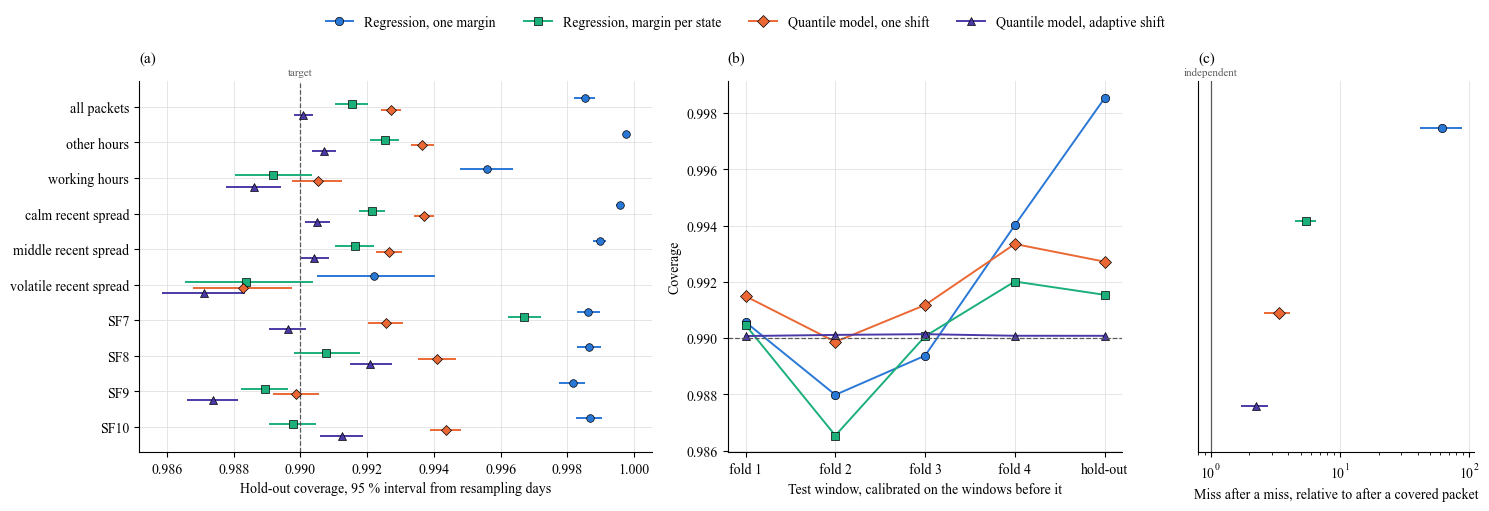

In [11]:
# Figure: where coverage fails, how it drifts across windows, and how the misses cluster (99 %)
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"], "font.size": 10})
shown = {"reg pooled": ("Regression, one margin", "#2a78d6", "o"), "reg state table": ("Regression, margin per state", "#1baf7a", "s"),
         "q pooled": ("Quantile model, one shift", "#eb6834", "D"), "q ACI": ("Quantile model, adaptive shift", "#4a3aa7", "^")}
names = {("all", "all"): "all packets", ("hours", "0"): "other hours", ("hours", "1"): "working hours", ("spread", "0"): "calm recent spread",
         ("spread", "1"): "middle recent spread", ("spread", "2"): "volatile recent spread", ("SF", "7"): "SF7", ("SF", "8"): "SF8", ("SF", "9"): "SF9", ("SF", "10"): "SF10"}
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.3, 1, 0.7]})
for j, (method, (label, colour, marker)) in enumerate(shown.items()):
    h = holdout[holdout.method == method].set_index(["group_type", "group"]).loc[list(names)]
    y_pos = np.arange(len(names))[::-1] + (1.5 - j) * 0.16
    ax[0].errorbar(h.coverage, y_pos, xerr=[h.coverage - h.lo, h.hi - h.coverage], fmt=marker, color=colour, ms=5.5, mec="black", mew=0.5, lw=1.4, capsize=0)
    c = table[(table.tau == 0.99) & (table.method == method) & (table.group_type == "all")].sort_values("window")
    ax[1].plot(range(len(c)), c.coverage, marker + "-", color=colour, ms=6, mec="black", mew=0.5, lw=1.4, label=label)
    i = independence[(independence.window == 9) & (independence.method == method)].iloc[0]
    ax[2].errorbar(i.ratio, 3 - j, xerr=[[i.ratio - i.lo], [i.hi - i.ratio]], fmt=marker, color=colour, ms=6, mec="black", mew=0.5, lw=1.4, capsize=0)
ax[0].set_yticks(np.arange(len(names))[::-1], list(names.values()))
ax[0].set_xlabel("Hold-out coverage, 95 % interval from resampling days")
ax[0].axvline(0.99, color="0.35", lw=0.9, ls="--")
ax[0].text(0.99, 1.01, "target", transform=ax[0].get_xaxis_transform(), ha="center", va="bottom", fontsize=8, color="0.35")
ax[1].set_xticks(range(len(windows)), [f"fold {w}" if w < 9 else "hold-out" for w in windows])
ax[1].set_ylabel("Coverage")
ax[1].set_xlabel("Test window, calibrated on the windows before it")
ax[1].axhline(0.99, color="0.35", lw=0.9, ls="--")
ax[2].set_xscale("log")
ax[2].axvline(1, color="0.35", lw=0.9)
ax[2].text(1, 1.01, "independent", transform=ax[2].get_xaxis_transform(), ha="center", va="bottom", fontsize=8, color="0.35")
ax[2].set_yticks([])
ax[2].set_ylim(-0.5, len(shown) - 0.5)
ax[2].set_xlabel("Miss after a miss, relative to after a covered packet")
for a_, tag in zip(ax, "abc"):
    a_.grid(color="0.88", lw=0.6)
    a_.set_axisbelow(True)
    a_.set_title(f"({tag})", loc="left", fontsize=11, pad=14)
    for sp in ("top", "right"):
        a_.spines[sp].set_visible(False)
handles, labels = ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.07))
fig.tight_layout()
fig.savefig("Figures/margin_calibration.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading of the results, 99 % target.**

* **A pooled shift drifts with the regime.** One margin from all earlier validation packets covers between 98.8 and 99.4 % in the validation windows and 99.85 % on the hold-out, which has no SF11 or SF12 and is a summer window. In the four validation windows its worst state is always SF12, covered at 93.7 to 94.5 %, while every other spreading factor is covered at 99.5 % or more: the SF12 packets are pooled with the rest.
* **Knowing the state is most of the gain.** A margin per group of spreading factor and working hours cuts the pinball loss of the regression on the hold-out from 87.6 to 65.3 per thousand, and adding the recent-spread tercile, a table of 36 margins, to 63.0. The mean margin above the anchor falls from 7.9 to 4.7 dB, and the hold-out coverage from 99.85 to 99.15 %.
* **The quantile model is sharper than the table, and not by much.** Against the 36-cell table its pinball loss is 4.1 lower per thousand, with an interval from 3.1 to 5.5, about 6.5 %. Its coverage in the volatile third is level with the table (difference 0.0 points, interval -0.2 to +0.1) and 0.8 points above the 12-cell table (interval +0.5 to +1.0). Conditional coverage therefore comes from knowing the state, by a table or by a model, not from the quantile model as such.
* **Adaptive conformal inference removes the drift.** Coverage is 99.0 % in every window for both base predictors, where the pooled shift moves between 98.8 and 99.85 %. In the window with the heaviest tail, validation fold 3, it lowers the pinball loss of the quantile model by 32 % (difference 41.7 per thousand, interval 10.4 to 86.3). On the hold-out it lowers the mean margin of the quantile model from 4.68 to 4.45 dB. Its states are covered at 98.7 to 99.2 %, the volatile third, working hours and SF9 being 0.1 to 0.3 points below the target.
* **Misses cluster less the more the margin knows.** The chance of a miss right after a miss, relative to after a covered packet, is 62 for the regression with one margin, 10 with the 12-cell table, 5.5 with the 36-cell table, 3.4 for the quantile model with one shift and 2.3 with the adaptive shift (interval 1.7 to 2.8). No method reaches independence. The Wald test of the misses on the previous miss and the state rejects for every method with half a million packets, so the effect sizes matter: the chance of a miss across the states ranges from 0 to 15 % for the regression with one margin and from 0.7 to 3.6 % for the quantile model with the adaptive shift, against a target of 1 %.
* **Settings.** A recency half-life of 7, 30 or 120 days and an adaptive step of the target gap divided by 100, 20 or 4 change the hold-out pinball loss by less than 2 %.
* **Recommendation.** With feedback from the received packets, the quantile model with the adaptive shift: exact coverage in every window, the lowest loss in four of five windows and tied in the fifth, the lowest clustering. Without feedback, the quantile model calibrated per state, or the 36-cell table, whose hold-out pinball loss is about 8 % higher.